# Discrete Probability Distributions

## Learning Objectives

By the end of this notebook you will be able to:

1. Derive the **Bernoulli** and **Binomial** PMFs from first principles (counting + independence).
2. Derive the **Poisson** PMF as the limit of the Binomial for rare events.
3. Derive the **Geometric** PMF and explain the **memoryless property**.
4. Compute $E[X]$ and $\text{Var}(X)$ for each distribution.
5. Implement each PMF **from scratch**, then use `scipy.stats` for the professional version.
6. Recognise which distribution models which real-world scenario.

## Prerequisites

- [Module 01 — Probability Basics](../01_probability_basics/01_sample_spaces.ipynb), especially:
  - [02_combinatorics](../01_probability_basics/02_combinatorics.ipynb) — $\binom{n}{k}$
  - [05_random_variables](../01_probability_basics/05_random_variables.ipynb) — PMF, $E[X]$, $\text{Var}(X)$

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial, exp

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. The Bernoulli Distribution — A Single Trial

The simplest random variable: a single yes/no experiment.

> **Definition (Bernoulli).** A random variable $X$ has a *Bernoulli distribution* with parameter $p \in [0, 1]$, written $X \sim \text{Bernoulli}(p)$, if:
>
> $$P(X = 1) = p, \qquad P(X = 0) = 1 - p$$
>
> Compactly: $P(X = x) = p^x (1-p)^{1-x}$ for $x \in \{0, 1\}$.

**Examples:** coin flip ($p = 0.5$), defective item ($p = 0.02$), click on an ad ($p = 0.03$).

### Mean and variance

$$E[X] = 0 \cdot (1-p) + 1 \cdot p = p$$

$$E[X^2] = 0^2 \cdot (1-p) + 1^2 \cdot p = p$$

$$\text{Var}(X) = E[X^2] - (E[X])^2 = p - p^2 = p(1-p)$$

The variance is maximised at $p = 0.5$ (maximum uncertainty) and zero at $p = 0$ or $p = 1$ (certainty).

In [ ]:
# From scratch: Bernoulli PMF
def bernoulli_pmf(x, p):
    """P(X = x) for X ~ Bernoulli(p), x in {0, 1}."""
    return p**x * (1 - p) ** (1 - x)


p = 0.3
print(f"Bernoulli(p={p}):")
print(f"  P(X=0) = {bernoulli_pmf(0, p):.4f}")
print(f"  P(X=1) = {bernoulli_pmf(1, p):.4f}")
print(f"  E[X]   = {p}")
print(f"  Var(X) = {p * (1 - p):.4f}")

Bernoulli(p=0.3):
  P(X=0) = 0.7000
  P(X=1) = 0.3000
  E[X]   = 0.3
  Var(X) = 0.2100


---

## 2. The Binomial Distribution — Counting Successes

What happens when we repeat a Bernoulli trial $n$ times and count the successes? This is the **Binomial distribution** — the first named distribution most students encounter, and one of the most important in all of statistics.

> **Definition (Binomial).** If $X_1, X_2, \dots, X_n$ are independent $\text{Bernoulli}(p)$ trials, then $X = \sum_{i=1}^n X_i$ (the total number of successes) has a *Binomial distribution*:
>
> $$X \sim \text{Binomial}(n, p)$$

### Deriving the PMF

For $X = k$ successes in $n$ trials:

1. **Choose which $k$ trials are successes:** $\binom{n}{k}$ ways (from Module 01, notebook 02).
2. **Each specific pattern has probability:** $p^k (1-p)^{n-k}$ (by independence).

Therefore:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \qquad k = 0, 1, \dots, n$$

### Mean and variance

By linearity of expectation (Module 01, notebook 05):

$$E[X] = E\left[\sum_{i=1}^n X_i\right] = \sum_{i=1}^n E[X_i] = np$$

Since the $X_i$ are independent:

$$\text{Var}(X) = \sum_{i=1}^n \text{Var}(X_i) = np(1-p)$$

No need to sum over the full PMF — linearity does the work.

In [ ]:
# Stage 2: FROM SCRATCH — Binomial PMF
def binomial_pmf(k, n, p):
    """P(X = k) for X ~ Binomial(n, p)."""
    return comb(n, k) * p**k * (1 - p) ** (n - k)


# Example: n=20 coin flips, p=0.5
n, p = 20, 0.5
ks = range(n + 1)
pmf_vals = [binomial_pmf(k, n, p) for k in ks]

print(f"Binomial(n={n}, p={p}):")
print(f"  E[X]   = np = {n * p}")
print(f"  Var(X) = np(1-p) = {n * p * (1 - p)}")
print(f"  Sum of PMF = {sum(pmf_vals):.6f}  (must be 1.0)")

Binomial(n=20, p=0.5):
  E[X]   = np = 10.0
  Var(X) = np(1-p) = 5.0
  Sum of PMF = 1.000000  (must be 1.0)


In [ ]:
# Stage 3: PROFESSIONAL — scipy.stats
from scipy.stats import binom

dist = binom(n=20, p=0.5)
print(f"scipy E[X]   = {dist.mean()}")
print(f"scipy Var(X) = {dist.var()}")

# Verify our scratch implementation matches
for k in [0, 5, 10, 15, 20]:
    ours = binomial_pmf(k, 20, 0.5)
    theirs = dist.pmf(k)
    print(
        f"  k={k:2d}: scratch={ours:.8f}, scipy={theirs:.8f}, match={abs(ours - theirs) < 1e-12}"
    )

scipy E[X]   = 10.0
scipy Var(X) = 5.0
  k= 0: scratch=0.00000095, scipy=0.00000095, match=True
  k= 5: scratch=0.01478577, scipy=0.01478577, match=True
  k=10: scratch=0.17619705, scipy=0.17619705, match=True
  k=15: scratch=0.01478577, scipy=0.01478577, match=True
  k=20: scratch=0.00000095, scipy=0.00000095, match=True


### How the shape changes with $p$

The Binomial PMF shifts and reshapes as $p$ changes. The animation below shows this for $n = 20$: at $p = 0.5$ the distribution is symmetric, at low $p$ it's right-skewed, at high $p$ it's left-skewed.

In [5]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

Manim Community v0.18.1

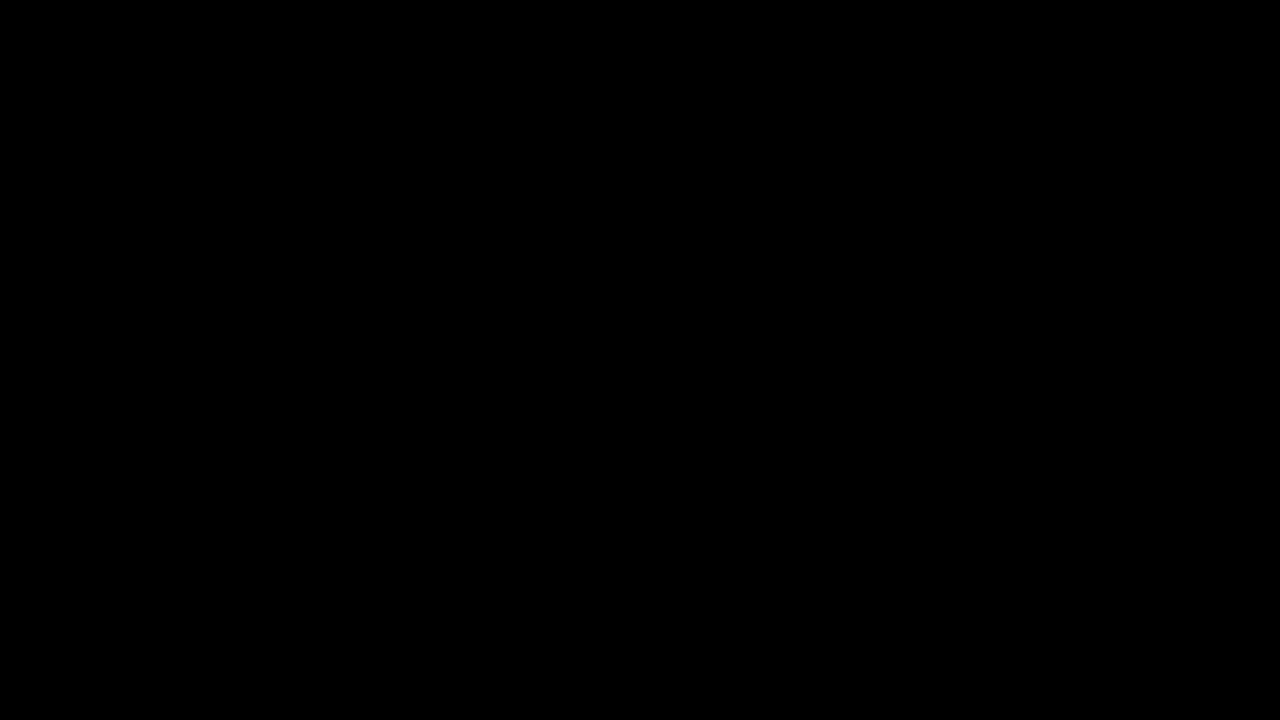

In [ ]:
%%manim -qm -v WARNING BinomialPMFMorph


class BinomialPMFMorph(Scene):
    """Animate the Binomial PMF as p changes from 0.1 to 0.9."""

    def construct(self):
        n = 20
        title = Text("Binomial(n=20, p) — PMF as p changes", font_size=28).to_edge(UP)
        self.play(Write(title))

        axes = Axes(
            x_range=[0, 20, 5],
            y_range=[0, 0.3, 0.05],
            x_length=10,
            y_length=4.5,
            axis_config={"include_numbers": True, "font_size": 18},
        ).shift(DOWN * 0.3)
        x_lbl = axes.get_x_axis_label(
            Text("k", font_size=20), edge=DOWN, direction=DOWN
        )
        y_lbl = axes.get_y_axis_label(
            Text("P(X=k)", font_size=18), edge=LEFT, direction=LEFT
        )
        self.play(Create(axes), Write(x_lbl), Write(y_lbl), run_time=0.8)

        def make_bars(p_val):
            bars = VGroup()
            for k in range(n + 1):
                prob = comb(n, k) * p_val**k * (1 - p_val) ** (n - k)
                h = max(prob * (4.5 / 0.3), 0.001)
                bar = Rectangle(
                    width=0.35,
                    height=h,
                    fill_color=C.PERIWINKLE,
                    fill_opacity=0.7,
                    stroke_color=WHITE,
                    stroke_width=0.5,
                ).move_to(axes.c2p(k, prob / 2))
                bars.add(bar)
            return bars

        p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
        bars = make_bars(p_values[0])
        p_label = math_text(
            rf"p = {p_values[0]}", font_size=26, color=C.GOLD
        ).to_corner(UR)
        self.play(FadeIn(bars), Write(p_label), run_time=0.8)

        for p_val in p_values[1:]:
            new_bars = make_bars(p_val)
            new_label = math_text(
                rf"p = {p_val}", font_size=26, color=C.GOLD
            ).to_corner(UR)
            self.play(
                Transform(bars, new_bars), Transform(p_label, new_label), run_time=1
            )
            self.wait(0.5)

        self.wait(1)

Watch how the "mass" slides from left to right as $p$ increases, and the spread (variance $= np(1-p)$) is widest at $p = 0.5$.

### Simulation: verifying the theory

Let's generate Binomial samples and compare the empirical histogram to the theoretical PMF — this is the same idea as Exercise 5.6 from Module 01, now with the theory behind it.

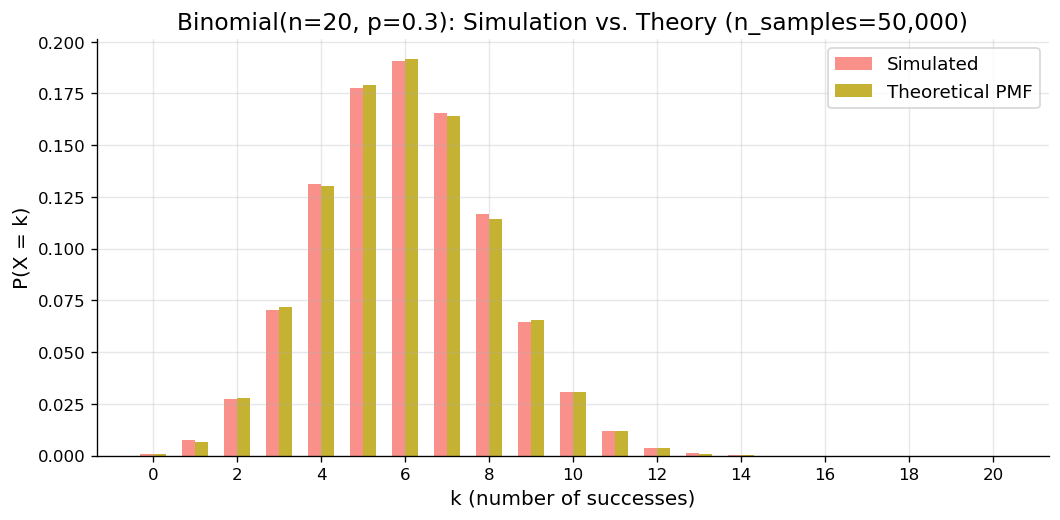

Theory:  E[X] = 6.0,  Var(X) = 4.20
Sample:  mean = 6.01,  var = 4.21


In [ ]:
# Simulation vs. theory for Binomial(n=20, p=0.3)
n, p = 20, 0.3
n_samples = 50_000

samples = rng.binomial(n, p, size=n_samples)

fig, ax = plt.subplots(figsize=(9, 4.5))
ks = np.arange(0, n + 1)

# Empirical
counts, _ = np.histogram(samples, bins=np.arange(-0.5, n + 1.5))
ax.bar(ks - 0.15, counts / n_samples, width=0.3, label="Simulated", alpha=0.8)

# Theoretical
theory = [binomial_pmf(k, n, p) for k in ks]
ax.bar(ks + 0.15, theory, width=0.3, label="Theoretical PMF", alpha=0.8)

ax.set_xlabel("k (number of successes)")
ax.set_ylabel("P(X = k)")
ax.set_title(f"Binomial(n={n}, p={p}): Simulation vs. Theory (n_samples={n_samples:,})")
ax.legend()
ax.set_xticks(range(0, n + 1, 2))
plt.tight_layout()
plt.show()

print(f"Theory:  E[X] = {n * p:.1f},  Var(X) = {n * p * (1 - p):.2f}")
print(f"Sample:  mean = {samples.mean():.2f},  var = {samples.var():.2f}")

---

## 3. The Poisson Distribution — Counting Rare Events

The Poisson distribution arises as the limit of the Binomial when $n$ is large and $p$ is small, but the expected count $\lambda = np$ stays fixed. This models **rare events in a fixed interval**: emails per hour, typos per page, accidents per year.

### Derivation from the Binomial

Start with $X \sim \text{Binomial}(n, \lambda/n)$ and let $n \to \infty$:

$$P(X = k) = \binom{n}{k} \left(\frac{\lambda}{n}\right)^k \left(1 - \frac{\lambda}{n}\right)^{n-k}$$

As $n \to \infty$: $\binom{n}{k}/n^k \to 1/k!$, and $(1 - \lambda/n)^{n-k} \to e^{-\lambda}$. So:

> **Definition (Poisson).** $X \sim \text{Poisson}(\lambda)$ has PMF:
>
> $$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \qquad k = 0, 1, 2, \dots$$

### Mean and variance

A remarkable property of the Poisson: **the mean equals the variance**.

$$E[X] = \lambda, \qquad \text{Var}(X) = \lambda$$

This is inherited from the Binomial limit: $np = \lambda$ and $np(1-p) = \lambda(1 - \lambda/n) \to \lambda$.

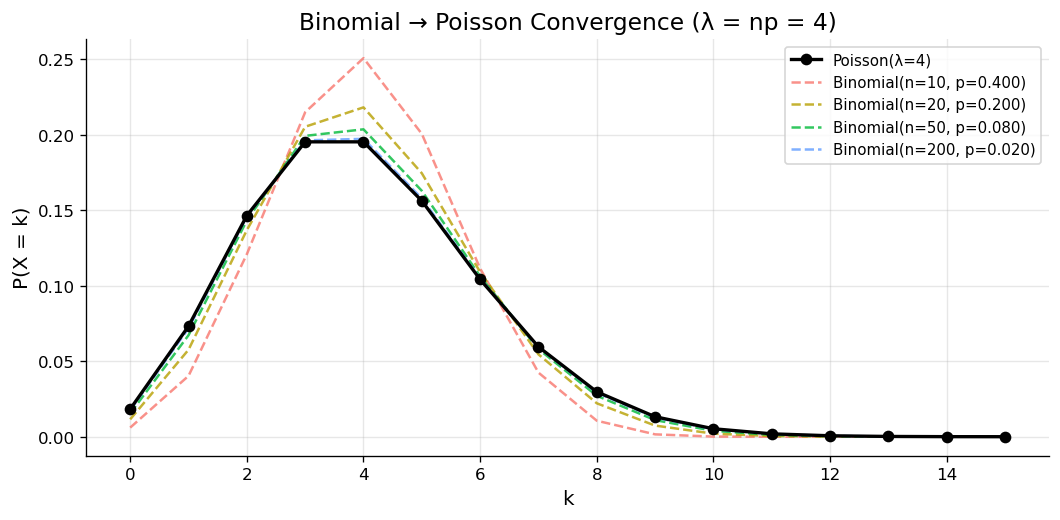

In [ ]:
# Stage 2: FROM SCRATCH — Poisson PMF
def poisson_pmf(k, lam):
    """P(X = k) for X ~ Poisson(λ)."""
    return exp(-lam) * lam**k / factorial(k)


# Show the Binomial → Poisson convergence
lam = 4
fig, ax = plt.subplots(figsize=(9, 4.5))
ks = np.arange(0, 16)

# Poisson(λ=4)
poisson_vals = [poisson_pmf(k, lam) for k in ks]
ax.plot(
    ks,
    poisson_vals,
    "ko-",
    linewidth=2,
    markersize=6,
    label=f"Poisson(λ={lam})",
    zorder=5,
)

# Binomial(n, p=λ/n) for increasing n
for n_binom, color in [
    (10, "#F8766D"),
    (20, "#B79F00"),
    (50, "#00BA38"),
    (200, "#619CFF"),
]:
    p_binom = lam / n_binom
    binom_vals = [binomial_pmf(k, n_binom, p_binom) for k in ks]
    ax.plot(
        ks,
        binom_vals,
        "--",
        color=color,
        linewidth=1.5,
        alpha=0.8,
        label=f"Binomial(n={n_binom}, p={p_binom:.3f})",
    )

ax.set_xlabel("k")
ax.set_ylabel("P(X = k)")
ax.set_title(f"Binomial → Poisson Convergence (λ = np = {lam})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
# Stage 3: PROFESSIONAL — scipy.stats.poisson
from scipy.stats import poisson

dist_p = poisson(mu=4)
print(f"Poisson(λ=4): E[X] = {dist_p.mean()}, Var(X) = {dist_p.var()}  (both equal λ!)")

# Verify scratch vs. scipy
for k in [0, 2, 4, 8]:
    print(f"  k={k}: scratch={poisson_pmf(k, 4):.8f}, scipy={dist_p.pmf(k):.8f}")

Poisson(λ=4): E[X] = 4.0, Var(X) = 4.0  (both equal λ!)
  k=0: scratch=0.01831564, scipy=0.01831564
  k=2: scratch=0.14652511, scipy=0.14652511
  k=4: scratch=0.19536681, scipy=0.19536681
  k=8: scratch=0.02977018, scipy=0.02977018


---

## 4. The Geometric Distribution — Waiting for Success

How many independent Bernoulli trials do we need until the **first success**?

> **Definition (Geometric).** If each trial succeeds with probability $p$ (independently), then the number of trials until the first success $X \sim \text{Geometric}(p)$ has PMF:
>
> $$P(X = k) = (1-p)^{k-1} p, \qquad k = 1, 2, 3, \dots$$

The logic: the first $k-1$ trials fail (each with probability $1-p$), and the $k$-th succeeds (probability $p$).

### Mean and variance

$$E[X] = \frac{1}{p}, \qquad \text{Var}(X) = \frac{1-p}{p^2}$$

For a fair coin ($p = 0.5$), the expected number of flips until the first head is $1/0.5 = 2$.

### The memoryless property

The Geometric distribution has a unique property: **the past doesn't matter**.

$$P(X > m + n \mid X > m) = P(X > n)$$

If you've already failed $m$ times, the probability of needing at least $n$ more trials is the same as starting fresh. This is the *only* discrete distribution with this property.

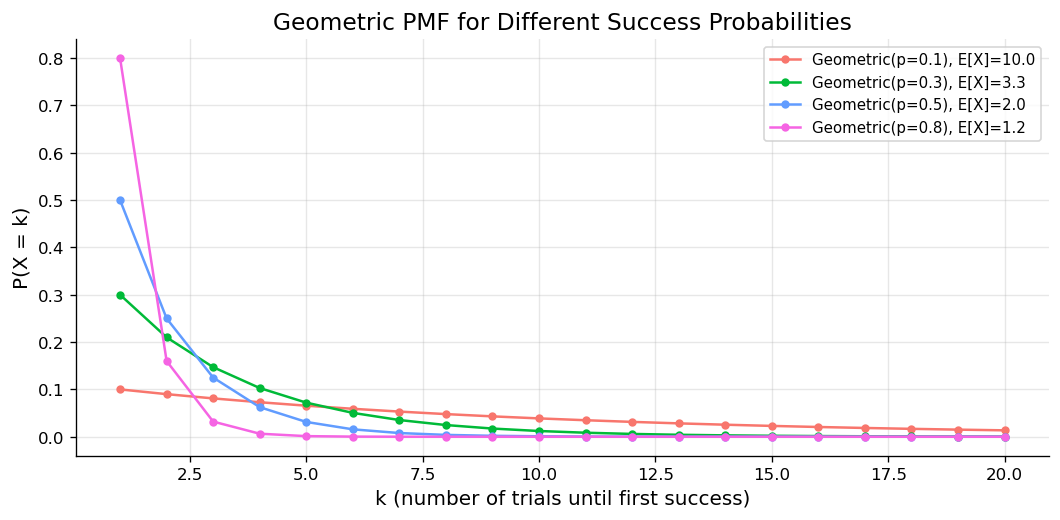

In [ ]:
# Stage 2: FROM SCRATCH — Geometric PMF
def geometric_pmf(k, p):
    """P(X = k) for X ~ Geometric(p), k = 1, 2, 3, ..."""
    return (1 - p) ** (k - 1) * p


# Plot for different p values
fig, ax = plt.subplots(figsize=(9, 4.5))
ks = np.arange(1, 21)

for p_val, color in [
    (0.1, "#F8766D"),
    (0.3, "#00BA38"),
    (0.5, "#619CFF"),
    (0.8, "#F564E3"),
]:
    vals = [geometric_pmf(k, p_val) for k in ks]
    ax.plot(
        ks,
        vals,
        "o-",
        color=color,
        linewidth=1.5,
        markersize=4,
        label=f"Geometric(p={p_val}), E[X]={1 / p_val:.1f}",
    )

ax.set_xlabel("k (number of trials until first success)")
ax.set_ylabel("P(X = k)")
ax.set_title("Geometric PMF for Different Success Probabilities")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Verify the memoryless property by simulation
p = 0.3
n_sims = 200_000

# Simulate geometric RVs (number of trials until first success)
samples = rng.geometric(p, size=n_sims)

# P(X > 5)
p_gt5 = np.mean(samples > 5)

# P(X > 8 | X > 3)  should equal P(X > 5)
survived_3 = samples[samples > 3]
p_gt8_given_gt3 = np.mean(survived_3 > 8)

print(f"Memoryless property check (p={p}):")
print(f"  P(X > 5)           = {p_gt5:.4f}")
print(f"  P(X > 8 | X > 3)   = {p_gt8_given_gt3:.4f}")
print(f"  Theory: (1-p)^5     = {(1 - p) ** 5:.4f}")

Memoryless property check (p=0.3):
  P(X > 5)           = 0.1671
  P(X > 8 | X > 3)   = 0.1677
  Theory: (1-p)^5     = 0.1681


---

## 5. Summary: Which Distribution When?

| Distribution  | Scenario                     | Parameters | $E[X]$    | $\text{Var}(X)$ | Python                     |
|---------------|------------------------------|------------|-----------|-----------------|----------------------------|
| **Bernoulli** | Single yes/no trial          | $p$        | $p$       | $p(1-p)$        | `scipy.stats.bernoulli(p)` |
| **Binomial**  | # successes in $n$ trials    | $n, p$     | $np$      | $np(1-p)$       | `scipy.stats.binom(n, p)`  |
| **Poisson**   | # events in fixed interval   | $\lambda$  | $\lambda$ | $\lambda$       | `scipy.stats.poisson(λ)`   |
| **Geometric** | # trials until first success | $p$        | $1/p$     | $(1-p)/p^2$     | `scipy.stats.geom(p)`      |

### Relationships

- **Bernoulli** is Binomial with $n = 1$.
- **Poisson** is the limit of Binomial when $n \to \infty$, $p \to 0$, $np = \lambda$.
- **Geometric** counts Bernoulli trials until the first success.
- For large $n$, Binomial approaches **Normal** (we'll see this in notebook 03 — the CLT).

---

## Exercises

**Exercise 1.1 (Binomial).** A multiple-choice test has 20 questions, each with 4 options. A student guesses randomly on every question. What is $P(\text{score} \geq 10)$? Compute analytically and verify with simulation.

**Exercise 1.2 (Poisson approximation).** A hospital averages 3 births per day. What is $P(\text{no births in a day})$? $P(\geq 5)$? Use both Poisson and simulation.

**Exercise 1.3 (Geometric).** On average, how many times must you roll a die to get a 6? Compute $E[X]$ analytically and verify by simulating 100,000 experiments.

**Exercise 1.4 (From scratch).** Implement `poisson_pmf_full(lam, max_k=30)` that returns the full PMF as a dict. Plot it for $\lambda = 1, 5, 10, 20$. What happens to the shape as $\lambda$ grows?

**Exercise 1.5 (Mean = Variance test).** Simulate 10,000 Poisson($\lambda = 7$) samples. Compute the sample mean and variance. How close are they? Now do the same for Binomial(100, 0.07). Why is the Binomial's variance slightly different?

**Exercise 1.6 (Challenge — Negative Binomial).** The *Negative Binomial* distribution counts the number of trials until the $r$-th success. Derive its PMF and show that it reduces to the Geometric when $r = 1$.

---

## Key Takeaways

1. **Bernoulli** is the building block — a single binary trial with parameter $p$.
2. **Binomial** counts successes in $n$ independent trials. PMF uses $\binom{n}{k}$ from combinatorics.
3. **Poisson** is the Binomial limit for rare events ($n$ large, $p$ small, $\lambda = np$ fixed). Its defining feature: $E[X] = \text{Var}(X) = \lambda$.
4. **Geometric** counts trials to the first success and is the only discrete memoryless distribution.
5. The **from-scratch → scipy.stats** pattern: we derived each PMF, implemented it, then showed scipy does the same.

**Next:** [02_continuous_distributions.ipynb](02_continuous_distributions.ipynb) — When the random variable can take any real value: Uniform, Normal, Exponential, and more.

In [12]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/BinomialPMFMorph@2026-03-19@15-56-51.gif
  ✓ media/gifs/CLTConvergence@2026-03-19@15-50-56.gif
  ✓ media/gifs/BinomialPMFMorph_ManimCE_v0.18.1.gif
  ✓ media/gifs/CLTConvergence_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
